In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [5]:
y_scores = model.predict_proba(X_test)[:,1]


In [6]:
y_scores

array([0.04953614, 0.17457598, 0.09361881, 0.25506885, 0.63547544,
       0.11671368, 0.06567023, 0.42188399, 0.04866172, 0.57563331,
       0.33875755, 0.41304766, 0.69854116, 0.19964149, 0.02001751,
       0.82471066, 0.86656925, 0.03101004, 0.25510704, 0.89492503,
       0.95246417, 0.83478816, 0.11740638, 0.44669903, 0.08923277,
       0.0688273 , 0.65117568, 0.41197875, 0.17860377, 0.28690155,
       0.24546297, 0.43904474, 0.00942529, 0.24260485, 0.35171265,
       0.96164606, 0.34360459, 0.80926014, 0.29380482, 0.0508316 ,
       0.18185164, 0.08671687, 0.42233336, 0.18738035, 0.03011578,
       0.03949078, 0.24740821, 0.42784702, 0.10529277, 0.37970704,
       0.99355928, 0.10665836, 0.39100545, 0.76883113, 0.36866729,
       0.45776991, 0.95035238, 0.41990462, 0.39153693, 0.04376   ,
       0.37295079, 0.90128751, 0.88176468, 0.88842753, 0.33083729,
       0.06930532, 0.9526512 , 0.20057864, 0.260557  , 0.35464146,
       0.10359002, 0.08168553, 0.45043617, 0.09221098, 0.08648

In [7]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

In [8]:
thresholds

array([       inf, 0.99355928, 0.9526512 , 0.95246417, 0.82471066,
       0.76883113, 0.76198112, 0.68385812, 0.67529148, 0.67422748,
       0.65117568, 0.65085312, 0.63547544, 0.58630057, 0.57563331,
       0.56974552, 0.52514581, 0.47017119, 0.46131937, 0.45043617,
       0.43904474, 0.43865745, 0.42233336, 0.41990462, 0.41304766,
       0.41197875, 0.40477801, 0.37970704, 0.36866729, 0.31020305,
       0.30880354, 0.27772349, 0.27205111, 0.25510704, 0.25506885,
       0.24740821, 0.24546297, 0.23665336, 0.22887288, 0.18185164,
       0.17860377, 0.17457598, 0.1732547 , 0.14638332, 0.14074927,
       0.11671368, 0.11494479, 0.11000892, 0.10665836, 0.08923277,
       0.08671687, 0.02001751, 0.01931547, 0.00160784])

In [9]:
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [10]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.36866729149373506


In [11]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score

# Assuming fpr, tpr, thresholds are already calculated as before
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_scores)

# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [13]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores) #use probability score and as in classification we use probability then set threshold
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


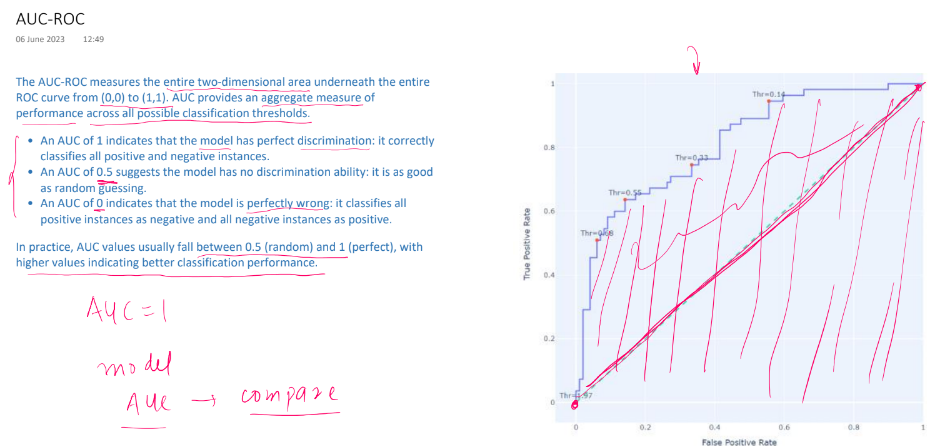


---

## 📊 ROC (Receiver Operating Characteristic)

- **What it is**: A **graph/diagram**
- **Plots**: True Positive Rate (TPR) vs. False Positive Rate (FPR) at different classification thresholds
- **Purpose**: Shows how well a model performs across **all possible thresholds**
- **Use Case**: Visualize trade-off between sensitivity and specificity

---

## 🧮 AUC (Area Under the Curve)

- **What it is**: A **single number**
- **Value Range**: 0 to 1
- **Meaning**: How well the model ranks positive instances higher than negative ones
- **Interpretation**:
  - **AUC = 1** → Perfect classifier
  - **AUC = 0.5** → Random guessing
  - **AUC > 0.5** → Better than random
- **Use Case**: Compare models numerically

---

## ✅ Summary: ROC vs AUC

| Feature       | ROC                              | AUC                              |
|---------------|----------------------------------|----------------------------------|
| Type          | Graph                            | Number                           |
| Shows         | TPR vs FPR at various thresholds | Overall model performance        |
| Use for       | Visual analysis                  | Model comparison                 |
| Tells you     | How model behaves with thresholds| How likely model ranks correctly |

---



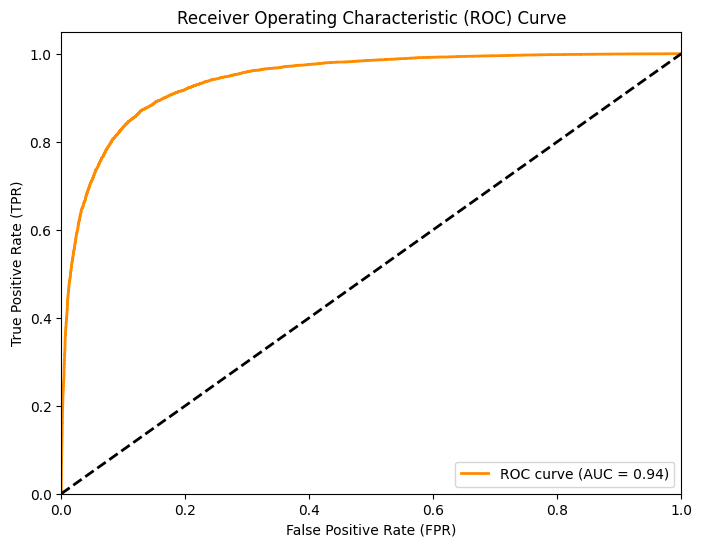

In [17]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,auc,roc_auc_score
import matplotlib.pyplot as plt

X,y = make_classification(n_samples = 100000,n_features = 20,random_state = 42)

X_train,X_test , y_train,y_test = train_test_split(X,y ,test_size = 0.25,random_state = 42)

model = LogisticRegression()
model.fit(X_train,y_train)

y_scores = model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_scores)
roc_auc = auc(fpr,tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Random guessing line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


---

## 🎯 Core Idea: Why ROC & AUC?

In machine learning, especially in classification problems, we often want to assess how well a model can distinguish between two classes — say, **positive (1)** and **negative (0)**.

But just looking at accuracy isn't enough when:

- The data is **imbalanced** (e.g., 99% negative samples).
- We care about **different types of errors**, like False Positives vs. False Negatives.

That’s where **ROC and AUC** come in handy. They evaluate how well a model ranks predictions across all possible decision thresholds.

---

## 🔍 What is ROC?

The **ROC curve** is a plot that illustrates the performance of a binary classifier system as its **discrimination threshold varies**.

It plots two metrics:

- **True Positive Rate (TPR)** or **Recall/Sensitivity**:  
  $$
  TPR = \frac{TP}{TP + FN}
  $$

- **False Positive Rate (FPR)**:  
  $$
  FPR = \frac{FP}{FP + TN}
  $$

### Confusion Matrix Recap:
| Actual ↓ / Predicted → | Positive (1) | Negative (0) |
|------------------------|--------------|--------------|
| **Positive (1)**       | TP           | FN           |
| **Negative (0)**       | FP           | TN           |

So, the **ROC curve** shows the trade-off between sensitivity (TPR) and specificity (1 - FPR) for different threshold values.

---

## 📈 What is AUC?

**AUC** stands for **Area Under the ROC Curve**.

It measures the entire two-dimensional area underneath the entire ROC curve from (0,0) to (1,1).

### Interpretation:

- **AUC = 1**: Perfect classifier.
- **AUC = 0.5**: Random guessing (no predictive power).
- **AUC < 0.5**: Worse than random; possibly inverted labels.

AUC gives you an **aggregate measure** of performance across all possible classification thresholds.

---

## 🧠 Intuition Behind AUC

Imagine your model outputs a **probability score** (like from logistic regression), not just a class label (0 or 1). AUC evaluates how well your model **ranks** positive instances higher than negatives.

If your model assigns higher scores to actual positives than actual negatives more often, AUC will be high.

> **AUC represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative one.**

---

## 📐 Math Behind AUC

Let’s assume we have:

- $ n_+ $: number of positive examples
- $ n_- $: number of negative examples

For every pair $(x_i^+, x_j^-)$, count how many times the score of $x_i^+$ > score of $x_j^-$.

Then:

$$
\text{AUC} = \frac{\text{Number of correct pairs}}{\text{Total number of pairs}} = \frac{\text{Correct}}{n_+ \cdot n_-}
$$

This is equivalent to the **Mann-Whitney U statistic**, which tests whether one group tends to have larger values than another.

---

## ✅ When Should You Use ROC-AUC?

Use AUC when:

- You care about **ranking performance**, not absolute probabilities.
- You're dealing with **imbalanced datasets**.
- You want to **compare different classifiers** without choosing a specific threshold.

---

## 🚫 Limitations of AUC

- It doesn’t reflect the **costs of different error types** (e.g., false positives might be more costly than false negatives).
- It can be misleading in **extremely imbalanced cases**.
- It assumes the model outputs **well-calibrated probabilities** (not always true).

---

## 🧪 Example Use Case

Suppose you're building a model to predict if a patient has cancer (positive class) or not (negative class).

You want to know:

- At what threshold should you call a result "positive"?
- How well does the model separate the two groups?

ROC helps visualize this. AUC summarizes it numerically.

---

## 💻 Code: Plotting ROC and Calculating AUC in Python

We'll use `scikit-learn` to compute and plot ROC and AUC.

```python
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a classifier
model = LogisticRegression()
model.fit(X_train, y_train)

# Get predicted probabilities
y_scores = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Random guessing line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
```

---

## 🧠 Why All This Is Necessary?

1. **Model Evaluation Beyond Accuracy**: Especially useful when the cost of errors matters.
2. **Threshold Selection**: Helps choose optimal thresholds based on trade-offs.
3. **Comparing Models**: AUC lets you compare models fairly, regardless of threshold choice.
4. **Understanding Model Behavior**: Shows how the model performs across all possible thresholds.

---

## 🧩 Bonus: Thresholds and Their Impact

Each point on the ROC curve corresponds to a **threshold** value.

For example:

- High threshold → fewer positives predicted → low TPR, low FPR
- Low threshold → more positives predicted → high TPR, high FPR

By varying the threshold, you can adjust the balance between catching more positives and avoiding false alarms.

---

## 📚 Summary Table

| Term        | Full Name                        | Formula                          | Meaning                                  |
|-------------|----------------------------------|-----------------------------------|------------------------------------------|
| TPR         | True Positive Rate               | TP / (TP + FN)                   | Recall / Sensitivity                     |
| FPR         | False Positive Rate              | FP / (FP + TN)                   | 1 - Specificity                          |
| AUC         | Area Under Curve                 | Integral of ROC curve            | Overall model performance                |
| ROC         | Receiver Operating Characteristic| Plot of TPR vs FPR               | Trade-off between sensitivity/specificity|

---

## 🧠 Final Thought

ROC and AUC are powerful because they abstract away the **specific decision threshold** and give a holistic view of model performance.

They help answer:

> "How well does my model distinguish between the two classes **regardless of the threshold**?"

This makes them indispensable in fields like healthcare, finance, and any domain where model reliability matters.

---





---

## 📊 ROC (Receiver Operating Characteristic)

- **What it is**: A **graph/diagram**
- **Plots**: True Positive Rate (TPR) vs. False Positive Rate (FPR) at different classification thresholds
- **Purpose**: Shows how well a model performs across **all possible thresholds**
- **Use Case**: Visualize trade-off between sensitivity and specificity

---

## 🧮 AUC (Area Under the Curve)

- **What it is**: A **single number**
- **Value Range**: 0 to 1
- **Meaning**: How well the model ranks positive instances higher than negative ones
- **Interpretation**:
  - **AUC = 1** → Perfect classifier
  - **AUC = 0.5** → Random guessing
  - **AUC > 0.5** → Better than random
- **Use Case**: Compare models numerically

---

## ✅ Summary: ROC vs AUC

| Feature       | ROC                              | AUC                              |
|---------------|----------------------------------|----------------------------------|
| Type          | Graph                            | Number                           |
| Shows         | TPR vs FPR at various thresholds | Overall model performance        |
| Use for       | Visual analysis                  | Model comparison                 |
| Tells you     | How model behaves with thresholds| How likely model ranks correctly |

---

